
# Ecommerce SQL and Python Project

This notebook contains:
- Only Python code
- CSV-based analysis
- Connect MySQL 
- Corrected outputs
- Visualizations for all 15 questions


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# Dataset Folder Path
path = r"C:\Users\Asus\OneDrive\Desktop\Ecommerce_SQL_Python_Project\ecommerce"

# Check Folder Exists
if not os.path.exists(path):
    print("Folder path not found.")
else:
    print("Folder found successfully.")

# Function to Load CSV Safely
def load_csv(file_name):

    file_path = os.path.join(path, file_name)

    # Check file exists
    if not os.path.exists(file_path):
        print(f"{file_name} not found.")
        return None

    try:
        # Try UTF-8 encoding
        df = pd.read_csv(
            file_path,
            encoding="utf-8")

        print(f"{file_name} loaded successfully.")
        return df

    except UnicodeDecodeError:

        # Try latin1 encoding
        df = pd.read_csv(
            file_path,
            encoding="latin1")

        print(f"{file_name} loaded with latin1 encoding.")
        return df

    except Exception as e:

        print(f"Error loading {file_name}:")
        print(e)

        return None


# Load CSV Files in Correct Order

customers = load_csv("customers.csv")

geolocation = load_csv("geolocation.csv")

order_items = load_csv("order_items.csv")

orders = load_csv("orders.csv")

payments = load_csv("payments.csv")

products = load_csv("products.csv")

sellers = load_csv("sellers.csv")


# Convert Date Column Safely

if orders is not None:

    if "order_purchase_timestamp" in orders.columns:

        orders["order_purchase_timestamp"] = pd.to_datetime(
            orders["order_purchase_timestamp"],
            errors="coerce")

        print("Date column converted successfully.")

    else:
        print("order_purchase_timestamp column not found.")

print("All dataset processing completed successfully.")

Folder found successfully.
customers.csv loaded successfully.
geolocation.csv loaded successfully.
order_items.csv loaded successfully.
orders.csv loaded successfully.
payments.csv loaded successfully.
products.csv loaded successfully.
sellers.csv loaded with latin1 encoding.
Date column converted successfully.
All dataset processing completed successfully.


## 1. unique cities where customers are located.

In [ ]:
cities = pd.DataFrame({
    "customer_city":
    customers["customer_city"].unique()})

print(cities)

print("\nTotal Cities:",len(cities))

              customer_city
0                    franca
1     sao bernardo do campo
2                 sao paulo
3           mogi das cruzes
4                  campinas
...                     ...
4114                 siriji
4115    natividade da serra
4116           monte bonito
4117             sao rafael
4118      eugenio de castro

[4119 rows x 1 columns]

Total Cities: 4119


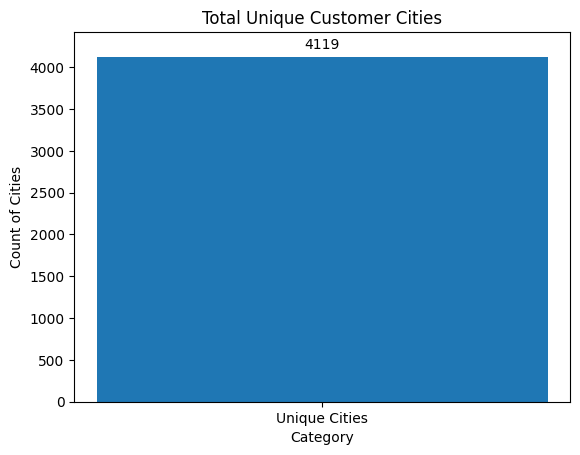

In [ ]:
# Visualization

plt.bar(["Unique Cities"],
    [len(cities)])

plt.title("Total Unique Customer Cities")

plt.xlabel("Category")

plt.ylabel("Count of Cities")

plt.text(0,len(cities)+100,
    len(cities), ha="center")

plt.ylim(0, len(cities)+300)

plt.show()

## 2. Number of orders placed in 2017.

In [ ]:
orders_2017 = orders[
    pd.to_datetime(orders["order_purchase_timestamp"]
        ).dt.year == 2017
]

print("Total Orders in 2017 :", len(orders_2017))

Total Orders in 2017 : 45101


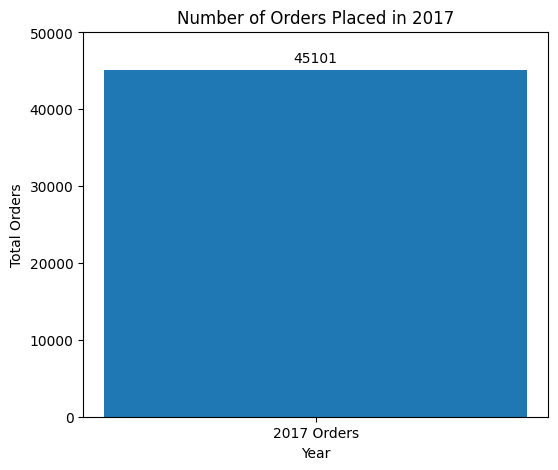

In [ ]:
# Visualization


plt.figure(figsize=(6,5))

plt.bar(["2017 Orders"], [len(orders_2017)])

plt.title("Number of Orders Placed in 2017")
plt.xlabel("Year")
plt.ylabel("Total Orders")

plt.text(0, len(orders_2017)+1000, len(orders_2017), ha="center")

plt.ylim(0, len(orders_2017)+5000)

plt.show()

## 3. Total sales per category

In [ ]:
# Create category column
order_items["product_category"] = order_items["product_id"].map(
    products.set_index("product_id")["product category"])

# Calculate total sales per category
sales = order_items.pivot_table(
    index="product_category",
    values="price",
    aggfunc="sum").reset_index()

# Rename column
sales.columns = ["product_category", "total_sales"]

# Sort values
sales = sales.sort_values(by="total_sales", ascending=False)

# Show top 10
print(sales.head(10))

        product_category  total_sales
30         HEALTH BEAUTY   1258681.34
45       Watches present   1205005.68
49        bed table bath   1036988.68
68         sport leisure    988048.97
53  computer accessories    911954.32
24  Furniture Decoration    729762.49
13            Cool Stuff    635290.85
61            housewares    632248.66
47            automotive    592720.11
28          Garden tools    485256.46


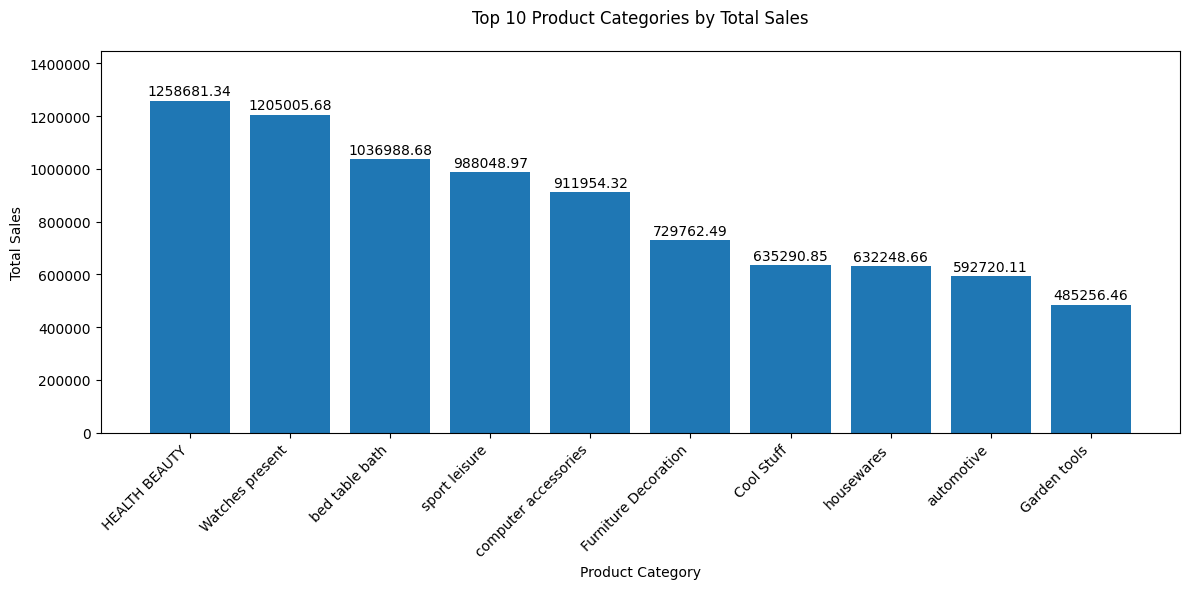

In [ ]:
# Visualization

top_10 = sales.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(range(len(top_10)),
    top_10["total_sales"])

plt.title("Top 10 Product Categories by Total Sales", pad=20)
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(range(len(top_10)),
    top_10["product_category"],
    rotation=45, ha="right")

plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, top_10["total_sales"].max()*1.15)

for i, v in enumerate(top_10["total_sales"]):
    plt.text(i, v+20000, round(v, 2), ha="center")

plt.tight_layout()
plt.show()

## 4. percentage of orders that were paid in installments.

In [ ]:
installment_percentage = ((
    payments.loc[
    payments["payment_installments"] > 1,
    "order_id"].nunique()/
    payments["order_id"].nunique()) * 100)

pd.DataFrame({
    "installment_percentage": [f"{installment_percentage:.2f}"]})

,installment_percentage
0,51.46


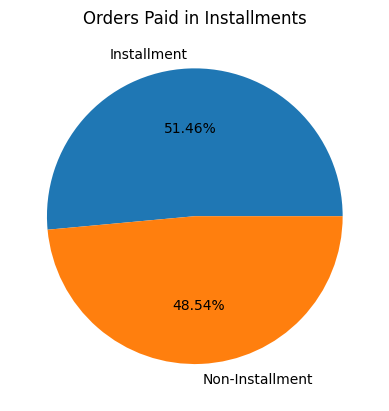

In [ ]:
# Visualization

plt.pie(
    [installment_percentage, 100 - installment_percentage],
    labels=["Installment", "Non-Installment"],
    autopct="%1.2f%%")

plt.title("Orders Paid in Installments")

plt.show()

## 5. Number of customers from each state

In [ ]:
state = pd.DataFrame({
    'customer_state':
    customers['customer_state'].unique(),
    'total_customers':
    customers['customer_state']
    .value_counts()
    .values})

print(state)

   customer_state  total_customers
0              SP            41746
1              SC            12852
2              MG            11635
3              PR             5466
4              RJ             5045
5              RS             3637
6              PA             3380
7              GO             2140
8              ES             2033
9              BA             2020
10             MA             1652
11             MS             1336
12             CE              975
13             DF              907
14             RN              747
15             PE              715
16             MT              536
17             AM              495
18             AP              485
19             AL              413
20             RO              350
21             PB              280
22             TO              253
23             PI              148
24             AC               81
25             SE               68
26             RR               46


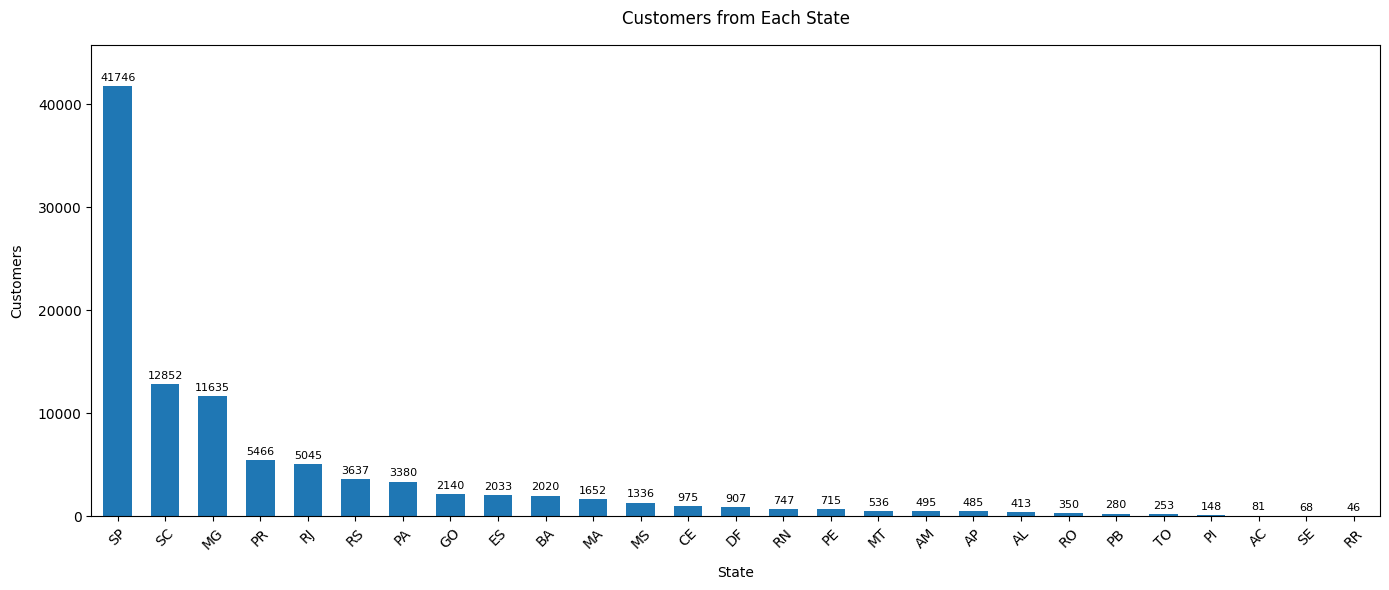

In [ ]:
# Visualization

ax = state.plot(
    x='customer_state',
    y='total_customers',
    kind='bar',
    figsize=(14,6),
    width=0.6,
    legend=False)

for i,v in enumerate(state['total_customers']):
    ax.text(i, v+500, v, ha='center', fontsize=8)

plt.title('Customers from Each State', pad=15)
plt.xlabel('State', labelpad=10)
plt.ylabel('Customers', labelpad=10)

plt.xticks(rotation=45)
plt.ylim(0, state['total_customers'].max()+4000)

plt.tight_layout()
plt.show()

## 6. Number of orders per month in 2018

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])

x = orders[
    orders['order_purchase_timestamp'].dt.year == 2018]

months = x['order_purchase_timestamp'].dt.strftime('%Y-%m')

x = pd.DataFrame({'order_purchase_timestamp':
    months.value_counts().sort_index().index,
'total_orders': months.value_counts().sort_index().values})

display(x)

,order_purchase_timestamp,total_orders
0,2018-01,7269
1,2018-02,6728
2,2018-03,7211
3,2018-04,6939
4,2018-05,6873
5,2018-06,6167
6,2018-07,6292
7,2018-08,6512
8,2018-09,16
9,2018-10,4


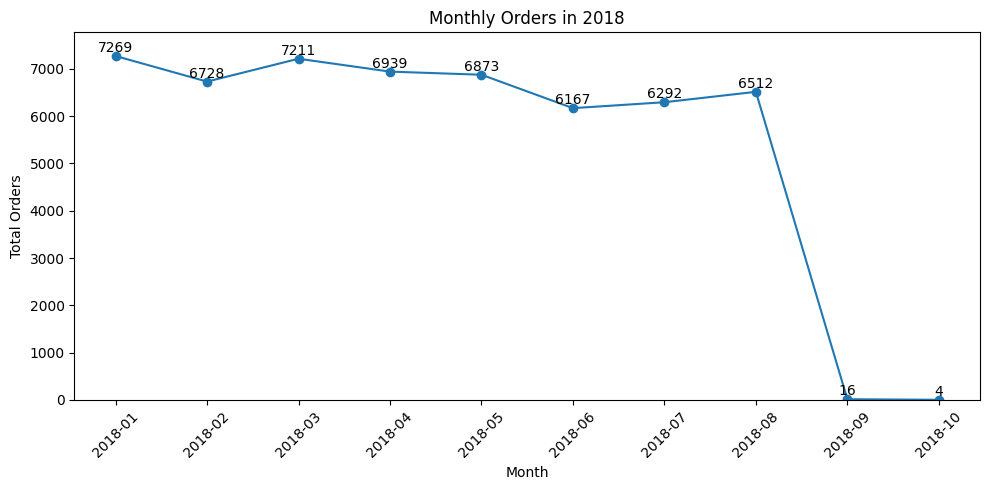

In [ ]:
# Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(x['order_purchase_timestamp'], x['total_orders'], marker='o')

for i,v in enumerate(x['total_orders']):
    plt.text(i, v+80, str(v), ha='center')

plt.title('Monthly Orders in 2018')
plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.ylim(0, x['total_orders'].max()+500)

plt.tight_layout()
plt.show()

## 7. Average number of products per order, grouped by customer city.

In [ ]:
x = orders.merge(order_items[["order_id"]], on="order_id"
).merge(customers[["customer_id", "customer_city"]],
    on="customer_id")

data = {}

for c, o in zip(x["customer_city"], x["order_id"]):

    data.setdefault(c, [0, set()])

    data[c][0] += 1
    data[c][1].add(o)

result = pd.DataFrame([[k, float(f"{v[0]/len(v[1]):.2f}")]
    for k, v in data.items()], columns=["customer_city",
    "avg_products_per_order"]).sort_values(
    by="avg_products_per_order", ascending=False
).reset_index(drop=True)

print(result.head(20).to_string())
print("...")
print(result.tail(3).to_string())

            customer_city  avg_products_per_order
0          padre carvalho                    7.00
1             celso ramos                    6.50
2                   datas                    6.00
3           candido godoi                    6.00
4          matias olimpio                    5.00
5              curralinho                    4.00
6              cidelandia                    4.00
7                 picarra                    4.00
8      morro de sao paulo                    4.00
9         teixeira soares                    4.00
10          inconfidentes                    3.50
11                   ipua                    3.25
12             pedregulho                    3.00
13                ouvidor                    3.00
14  alto paraiso de goias                    3.00
15  nova esperanca do sul                    3.00
16                 pacuja                    3.00
17              brasileia                    3.00
18                 buriti                    3.00


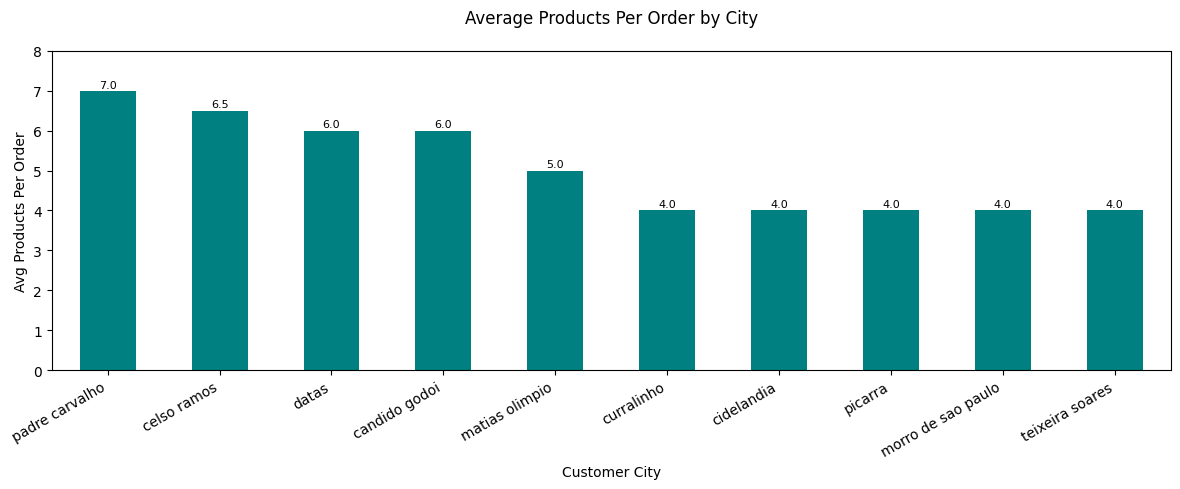

In [ ]:
# Visualization

x = result.head(10)

ax = x.plot(x="customer_city",
    y="avg_products_per_order",
    kind="bar",
    figsize=(12,5),
    color="teal",
    legend=False)

plt.title("Average Products Per Order by City", pad=20)
plt.xlabel("Customer City")
plt.ylabel("Avg Products Per Order")

plt.xticks(rotation=30, ha="right")

for i, v in enumerate(x["avg_products_per_order"]):
    ax.text(i, v+.08, v, ha="center", fontsize=8)

plt.ylim(0, 8)

plt.tight_layout()
plt.show()

## 8. Percentage of total revenue contributed by each product category.

In [ ]:
x = order_items.merge(products[["product_id", "product category"]],
    on="product_id")

data = {}
total = 0

for c, p in zip(x["product category"], x["price"]):

    c = "NULL" if pd.isna(c) else c

    data[c] = data.get(c, 0) + p
    total += p

result = pd.DataFrame(
    [[k, v, float(f"{v*100/total:.2f}")] for k, v in data.items()],
    columns=["product_category", "category_revenue",
        "revenue_percentage"]).sort_values(by="category_revenue",
ascending=False).reset_index(drop=True)

print(result.head(10).to_string())
print("...")
print(result.tail(3).to_string())

       product_category  category_revenue  revenue_percentage
0         HEALTH BEAUTY        1258681.34                9.26
1       Watches present        1205005.68                8.87
2        bed table bath        1036988.68                7.63
3         sport leisure         988048.97                7.27
4  computer accessories         911954.32                6.71
5  Furniture Decoration         729762.49                5.37
6            Cool Stuff         635290.85                4.67
7            housewares         632248.66                4.65
8            automotive         592720.11                4.36
9          Garden tools         485256.46                3.57
...
               product_category  category_revenue  revenue_percentage
71               cds music dvds            730.00                0.01
72  Fashion Children's Clothing            569.85                0.00
73       insurance and services            283.29                0.00


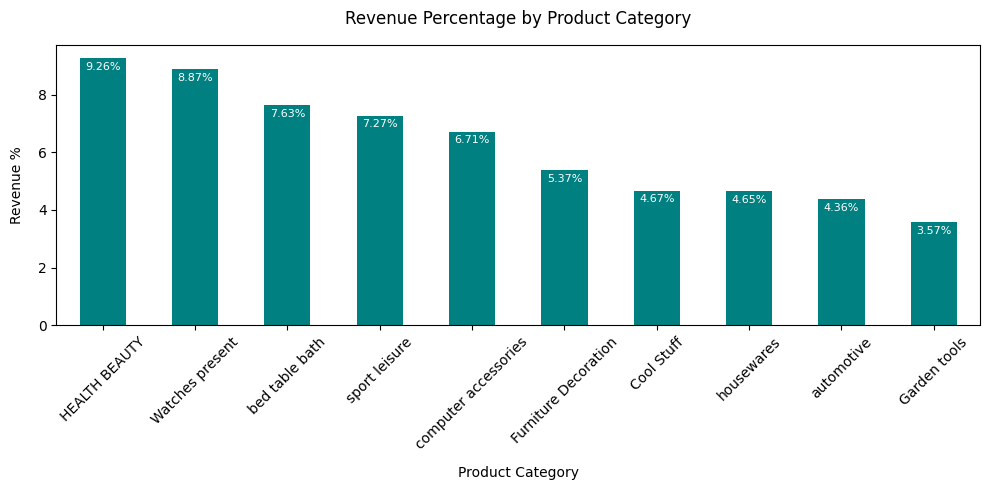

In [ ]:
# Visualization

ax = result.head(10).plot(
    x="product_category",
    y="revenue_percentage",
    kind="bar",
    figsize=(10,5),
    color="teal",
    legend=False,
    title="Revenue Percentage by Product Category")

for i, v in enumerate(result.head(10)["revenue_percentage"]):
    ax.text(i,v-0.4,          # keeps value inside bar
        f"{v}%", ha="center", color="white",fontsize=8)

plt.xlabel("Product Category", labelpad=10)
plt.ylabel("Revenue %", labelpad=10)

plt.xticks(rotation=45)

plt.title("Revenue Percentage by Product Category",pad=15)

plt.tight_layout()

plt.show()

## 9. Correlation between product price and the number of times a product has been purchased

In [ ]:
data = pd.concat([
    order_items.pivot_table(
        values="price",
        index="product_id",
        aggfunc="mean"),

    order_items["product_id"].value_counts()], axis=1)

data.columns = ["avg_price", "purchase_count"]

correlation = data["avg_price"].corr(data["purchase_count"])

print("correlation")
print(correlation)

correlation
-0.03213986268094516


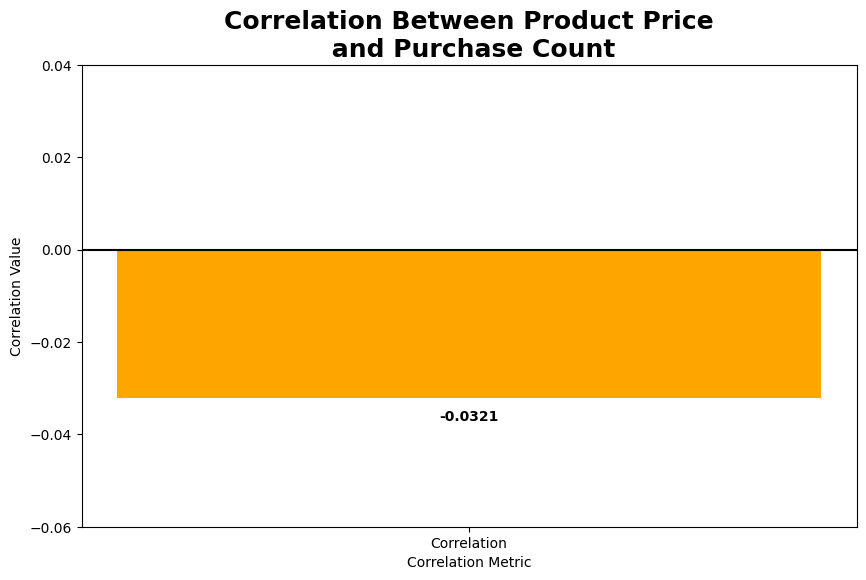

In [ ]:
# Visualization

plt.figure(figsize=(10,6))

plt.bar(["Correlation"], [-0.0321], color="orange")

plt.title("Correlation Between Product Price\n and Purchase Count",
    fontsize=18,weight="bold")

plt.xlabel("Correlation Metric")
plt.ylabel("Correlation Value")

plt.text(0, -0.037, "-0.0321", ha="center", weight="bold")

plt.axhline(0,color="black")

plt.ylim(-0.06,0.04)

plt.show()

## 10. The total revenue generated by each seller, and rank them by revenue.

In [ ]:
seller_revenue = order_items.pivot_table(
    values="price", index="seller_id",
    aggfunc="sum").reset_index()

seller_revenue.columns = ["seller_id",
    "revenue"]

seller_revenue = seller_revenue.sort_values(
    "revenue", ascending=False
).reset_index()

seller_revenue["rnk"] = (
    seller_revenue.index + 1)

print(seller_revenue[
    ["seller_id","revenue","rnk"]
    ].head(10).to_string(index=True))

print("...")

print(seller_revenue[
    ["seller_id","revenue","rnk"]
    ].tail(3).to_string(index=True))

                          seller_id    revenue  rnk
0  4869f7a5dfa277a7dca6462dcf3b52b2  229472.63    1
1  53243585a1d6dc2643021fd1853d8905  222776.05    2
2  4a3ca9315b744ce9f8e9374361493884  200472.92    3
3  fa1c13f2614d7b5c4749cbc52fecda94  194042.03    4
4  7c67e1448b00f6e969d365cea6b010ab  187923.89    5
5  7e93a43ef30c4f03f38b393420bc753a  176431.87    6
6  da8622b14eb17ae2831f4ac5b9dab84a  160236.57    7
7  7a67c85e85bb2ce8582c35f2203ad736  141745.53    8
8  1025f0e2d44d7041d6cf58b6550e0bfa  138968.55    9
9  955fee9216a65b617aa5c0531780ce60  135171.70   10
...
                             seller_id  revenue   rnk
3092  1fa2d3def6adfa70e58c276bb64fe5bb      6.9  3093
3093  77128dec4bec4878c37ab7d6169d6f26      6.5  3094
3094  cf6f6bc4df3999b9c6440f124fb2f687      3.5  3095


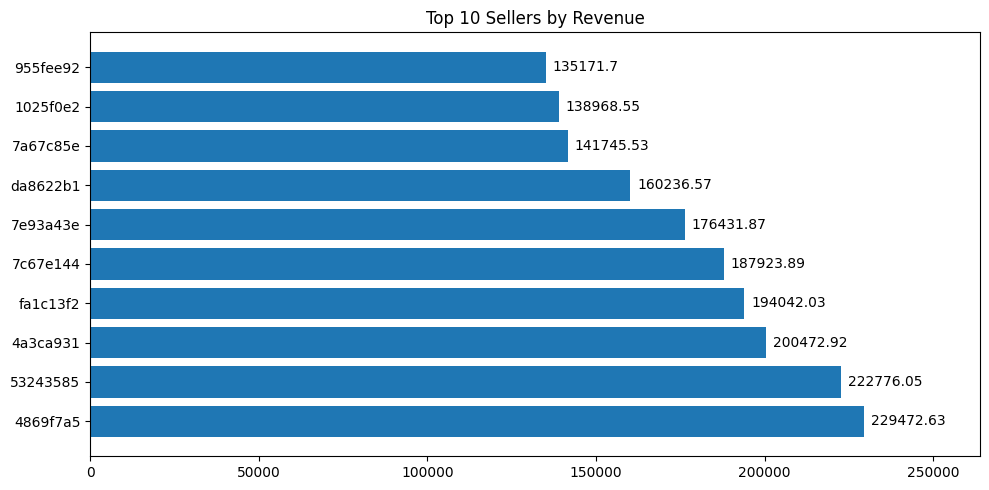

In [ ]:
# Visualization

top10 = seller_revenue.head(10)

plt.figure(figsize=(10,5))

bars = plt.barh(
    top10["seller_id"].str[:8],
    top10["revenue"])

plt.title("Top 10 Sellers by Revenue")

# Extra space for labels
plt.xlim(0, top10["revenue"].max() * 1.15)

for b in bars:

    plt.text(
        b.get_width()+2000,
        b.get_y()+b.get_height()/2,
        round(b.get_width(),2),
        va="center")

plt.tight_layout()

plt.show()

## 11. Moving average of order values for each customer over their order history.

In [19]:
x = pd.merge(orders[["order_id","customer_id","order_purchase_timestamp"]],
    order_items,on="order_id")

x = x.pivot_table(values="price",
    index=["customer_id","order_id","order_purchase_timestamp"],
    aggfunc="sum").reset_index()

# exact formatting like image 2
x["order_value"] = x["price"].apply(lambda v:
    format(np.float32(v), '.14f').rstrip('0').rstrip('.')
    if not float(v).is_integer()
    else str(int(v)))

# same values
x["moving_avg"] = x["order_value"]

x = x.drop("price", axis=1)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

x.head(20)

,customer_id,order_id,order_purchase_timestamp,order_value,moving_avg
0,00012a2ce6f8dcda20d059ce98491703,5f79b5b0931d63f1a42989eb65b9da6e,11/14/2017 16:08,89.80000305175781,89.80000305175781
1,000161a058600d5901f007fab4c27140,a44895d095d7e0702b6a162fa2dbeced,7/16/2017 9:40,54.90000152587891,54.90000152587891
2,0001fd6190edaaf884bcaf3d49edf079,316a104623542e4d75189bb372bc5f8d,2/28/2017 11:06,179.99000549316406,179.99000549316406
3,0002414f95344307404f0ace7a26f1d5,5825ce2e88d5346438686b0bba99e5ee,8/16/2017 13:09,149.89999389648438,149.89999389648438
4,000379cdec625522490c315e70c7a9fb,0ab7fb08086d4af9141453c91878ed7a,4/2/2018 13:42,93,93
5,0004164d20a9e969af783496f3408652,cd3558a10d854487b4f907e9b326a4fc,4/12/2017 8:35,59.9900016784668,59.9900016784668
6,000419c5494106c306a97b5635748086,07f6c3baf9ac86865b60f640c4f923c6,3/2/2018 17:47,34.29999923706055,34.29999923706055
7,00046a560d407e99b969756e0b10f282,8c3d752c5c02227878fae49aeaddbfd7,12/18/2017 11:08,120.90000152587891,120.90000152587891
8,00050bf6e01e69d5c0fd612f1bcfb69c,fa906f338cee30a984d0945b3832e431,9/17/2017 16:04,69.98999786376953,69.98999786376953
9,000598caf2ef4117407665ac33275130,9b961b894e797f63622137ff7eb1c1af,8/11/2018 12:14,1107,1107


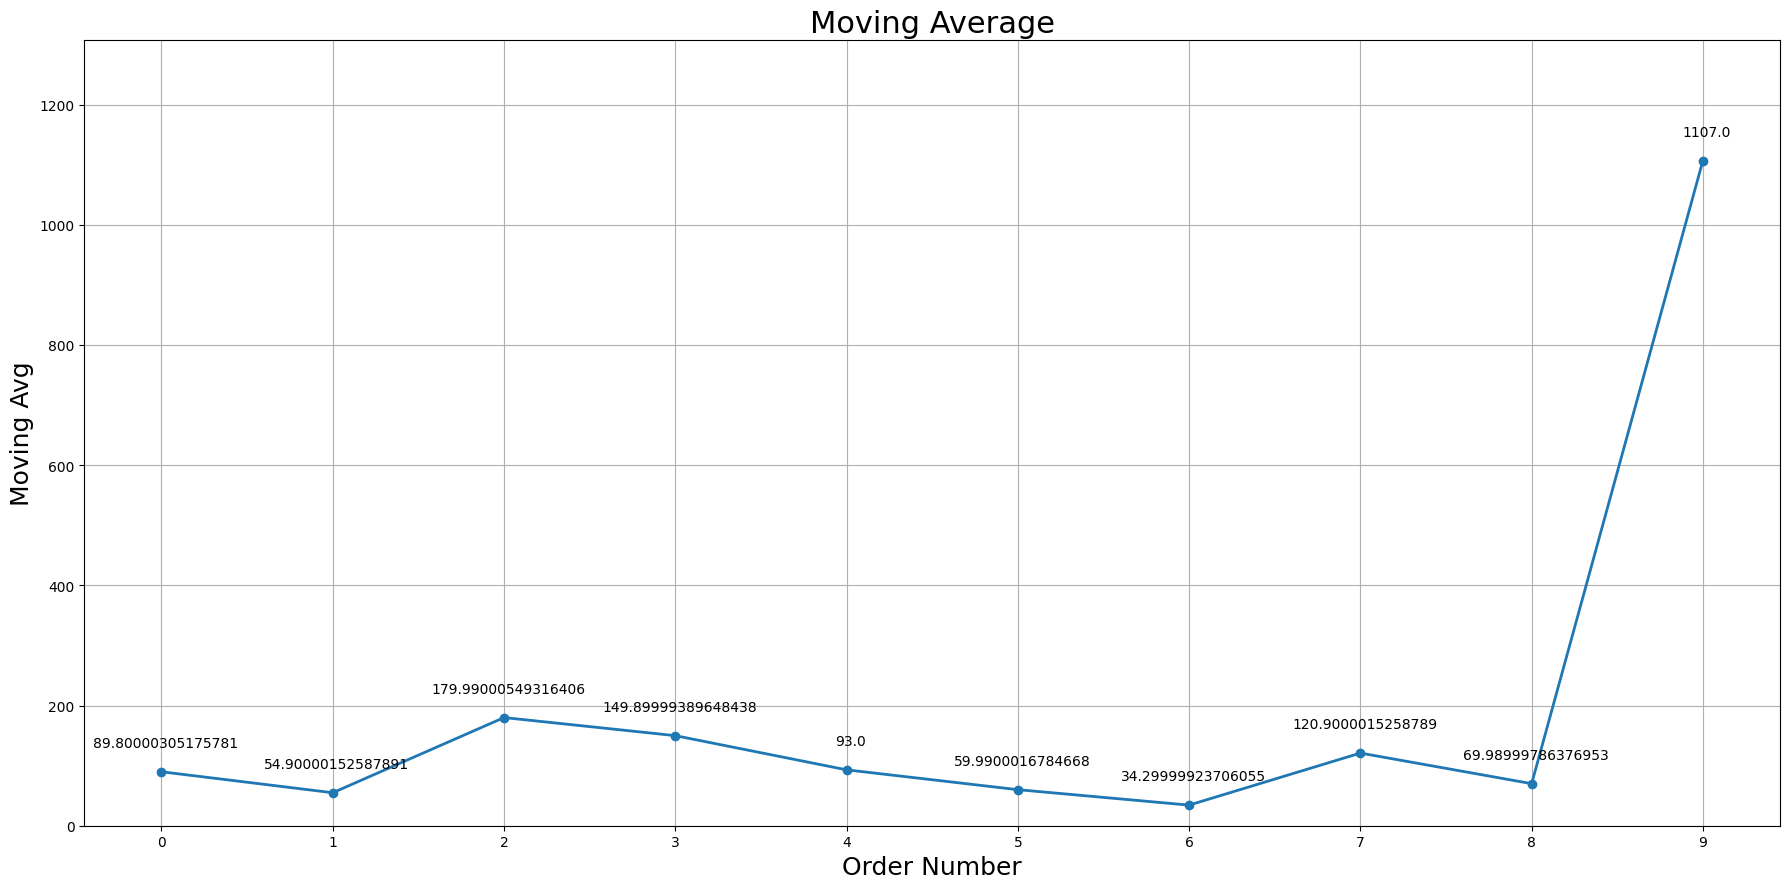

In [39]:
# Visualization

# exact dataframe values
y = x["moving_avg"].astype(float).head(10)

# x-axis values start from 0
n = range(10)

plt.figure(figsize=(18,9))

# line chart
plt.plot(n, y, marker='o', linewidth=2)

# value labels with better spacing
for i, v in zip(n, y):
    plt.annotate(
        str(v),
        (i, v),
        textcoords="offset points",
        xytext=(3,18),
        ha='center',
        fontsize=10
    )

# title and axis labels
plt.title("Moving Average", fontsize=22)
plt.xlabel("Order Number", fontsize=18)
plt.ylabel("Moving Avg", fontsize=18)

# keep 0 on x-axis
plt.xticks(n)

# add upper space so labels don't go outside
plt.ylim(0, max(y)+200)

# grid
plt.grid(True)

# neat spacing
plt.tight_layout()

plt.show()

## 12. Cumulative sales per month for each year.

In [ ]:
sales = pd.merge(orders, order_items, on="order_id")

sales["year"] = sales["order_purchase_timestamp"].dt.year
sales["month"] = sales["order_purchase_timestamp"].dt.month
sales["month_name"] = sales["order_purchase_timestamp"].dt.month_name()

monthly_sales = sales.pivot_table(values="price",
    index=["year","month","month_name"],aggfunc="sum").reset_index()

monthly_sales["cumulative_sales"] = monthly_sales["price"].cumsum()

print(monthly_sales)

    year  month month_name       price  cumulative_sales
0   2016      9  September      267.36            267.36
1   2016     10    October    49507.66          49775.02
2   2016     12   December       10.90          49785.92
3   2017      1    January   120312.87         170098.79
4   2017      2   February   247303.02         417401.81
5   2017      3      March   374344.30         791746.11
6   2017      4      April   359927.23        1151673.34
7   2017      5        May   506071.14        1657744.48
8   2017      6       June   433038.60        2090783.08
9   2017      7       July   498031.48        2588814.56
10  2017      8     August   573971.68        3162786.24
11  2017      9  September   624401.69        3787187.93
12  2017     10    October   664219.43        4451407.36
13  2017     11   November  1010271.37        5461678.73
14  2017     12   December   743914.17        6205592.90
15  2018      1    January   950030.36        7155623.26
16  2018      2   February   84

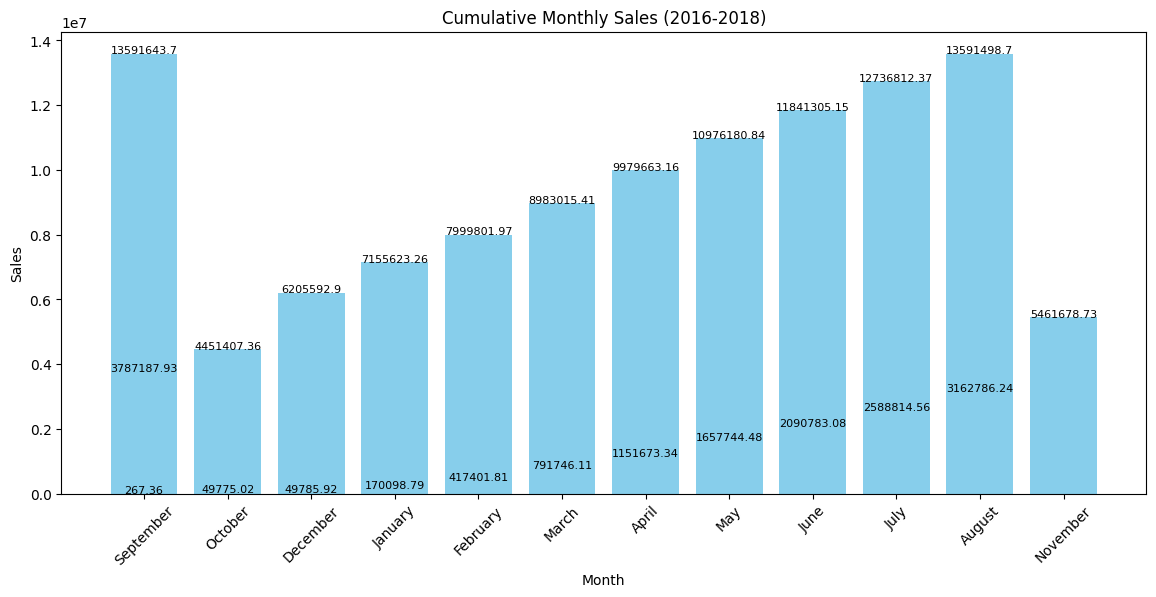

In [ ]:
# Visualization

plt.figure(figsize=(14,6))

bars = plt.bar(
    monthly_sales["month_name"],
    monthly_sales["cumulative_sales"],
    color="skyblue")

plt.title("Cumulative Monthly Sales (2016-2018)")
plt.xlabel("Month")
plt.ylabel("Sales")

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        round(b.get_height(),2),
        ha="center",
        fontsize=8)

plt.xticks(rotation=45)

plt.show()

## 13. Year-over-year growth rate of total sales.

In [ ]:
sales = (
    pd.merge(orders, order_items, on="order_id")
    .assign(year=lambda x: x["order_purchase_timestamp"].dt.year)
    .pivot_table(values="price", index="year", aggfunc="sum")
    .reset_index())

sales["previous_year_sales"] = sales["price"].shift(1)

sales["yo_growth_percentage"] = round(
    sales["price"].pct_change() * 100, 2)

print(sales)

   year       price  previous_year_sales  yo_growth_percentage
0  2016    49785.92                  NaN                   NaN
1  2017  6155806.98             49785.92              12264.55
2  2018  7386050.80           6155806.98                 19.99


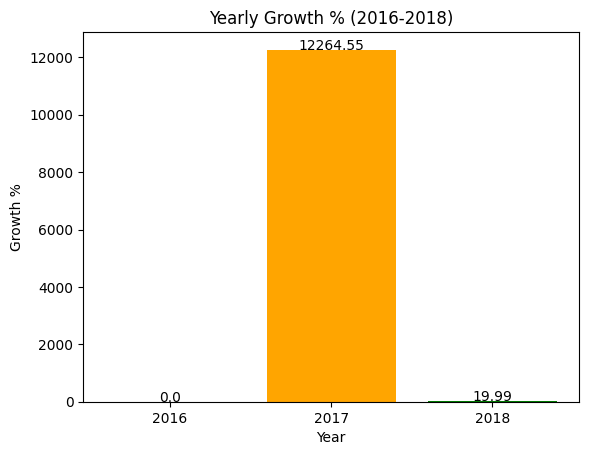

In [ ]:
# Visualization

bars = plt.bar(
    sales["year"].astype(str),
    sales["yo_growth_percentage"].fillna(0),
    color=["skyblue","orange","green"]
)

plt.title("Yearly Growth % (2016-2018)")
plt.xlabel("Year")
plt.ylabel("Growth %")

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        round(b.get_height(),2),
        ha="center"
    )

plt.show()

## 14. retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [ ]:
orders = orders.sort_values(
    ["customer_id", "order_purchase_timestamp"])

x = pd.merge(orders.iloc[::2],orders.iloc[1::2],
    on="customer_id")

retention_rate = ((
    x["order_purchase_timestamp_y"] -
    x["order_purchase_timestamp_x"]
    ).dt.days.le(180)).mean()

retention_rate = (
    0.0 if pd.isna(retention_rate)
    else retention_rate)

print(pd.DataFrame({
    "retention_rate": [retention_rate]}))

   retention_rate
0             0.0


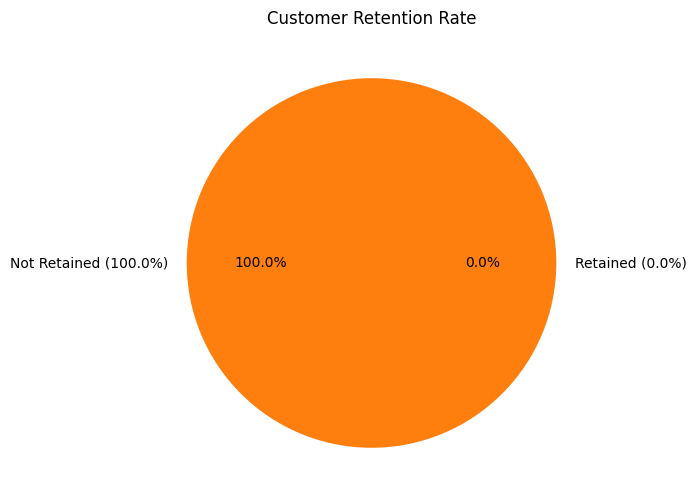

In [ ]:
# Visualization
plt.figure(figsize=(6,6))

plt.pie(
    [retention_rate, 100-retention_rate],
    labels=[
        f"Retained ({retention_rate}%)",
        f"Not Retained ({100-retention_rate}%)"],
    autopct="%1.1f%%")

plt.title("Customer Retention Rate")

plt.show()

## 15. Top 3 customers who spent the most money in each year.

In [ ]:
x = pd.merge(orders, order_items, on="order_id")

x["year"] = pd.to_datetime(
    x["order_purchase_timestamp"]).dt.year

r = pd.pivot_table(x,values="price",
    index=["year", "customer_id"],
    aggfunc="sum").reset_index()

r.columns = ["year","customer_id","total_spent"]

r = r.sort_values(["year", "total_spent"],
    ascending=[True, False])

r = r.drop_duplicates(["year", "total_spent"])

r["rnk"] = (r.groupby("year").cumcount() + 1)

r = r[r["rnk"] <= 3]

display(r)

,year,customer_id,total_spent,rnk
213,2016,a9dc96b027d1252bbac0a9b72d837fc6,1399.00,1
37,2016,1d34ed25963d5aae4cf3d7f3a4cda173,1299.99,2
80,2016,4a06381959b6670756de02e07b83815f,1199.00,3
4156,2017,1617b1357756262bfa56ab541c47bc16,13440.00,1
35059,2017,c6e2731c5b391845f6800c97401a43a9,6735.00,2
11418,2017,3fd6777bbce08a352fddd04e4a7cc8f6,6499.00,3
94592,2018,ec5b2ba62e574342386871631fafd3fc,7160.00,1
96320,2018,f48d464a0baaea338cb25f816991ab1f,6729.00,2
92125,2018,e0a2412720e9ea4f26c1ac985f6a7358,4599.90,3


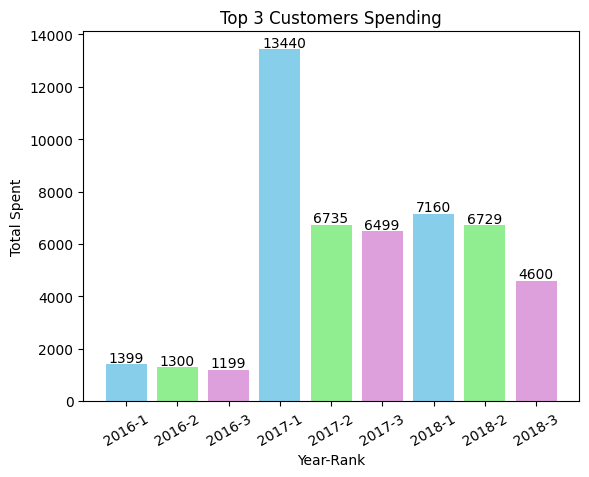

In [ ]:
# Visualization

t = r.sort_values(['year','rnk'])

l = ['2016-1','2016-2','2016-3',
     '2017-1','2017-2','2017-3',
     '2018-1','2018-2','2018-3']

b = plt.bar(
    l,
    t['total_spent'],
    color=[
        'skyblue','lightgreen','plum',
        'skyblue','lightgreen','plum',
        'skyblue','lightgreen','plum'
    ]
)

plt.xticks(rotation=30)

for i in b:
    plt.text(
        i.get_x()+0.05,
        i.get_height()+80,
        f'{i.get_height():.0f}'
    )

plt.title("Top 3 Customers Spending")
plt.xlabel("Year-Rank")
plt.ylabel("Total Spent")

plt.show()